In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import tensorflow as tf
from tensorflow import keras

In [3]:
from tensorflow.keras.preprocessing.image import load_img

In [4]:
path = 'D:/akjnm/Documents/Adam/Programming/clothing-dataset-small/train/t-shirt'
file = '00d9cc6e-2564-4813-9d68-4bc4d562107b.jpg'
img = load_img(f'{path}/{file}', target_size=(299, 299))

In [5]:
x = np.array(img)
x.shape

(299, 299, 3)

In [6]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input

In [7]:
model = Xception(weights='imagenet', input_shape=(299, 299, 3))

In [8]:
X = np.array([x])

In [9]:
X = preprocess_input(X)

In [10]:
X[0]

array([[[ 0.6784314 ,  0.64705884,  0.5764706 ],
        [ 0.48235297,  0.45098042,  0.3803922 ],
        [ 0.49803925,  0.4666667 ,  0.39607847],
        ...,
        [ 0.27058828,  0.2313726 ,  0.18431377],
        [ 0.67058825,  0.6313726 ,  0.58431375],
        [ 0.427451  ,  0.38823533,  0.3411765 ]],

       [[ 0.54509807,  0.5137255 ,  0.4431373 ],
        [ 0.54509807,  0.5137255 ,  0.4431373 ],
        [ 0.5058824 ,  0.47450984,  0.4039216 ],
        ...,
        [ 0.41960788,  0.3803922 ,  0.33333337],
        [ 0.5529412 ,  0.5137255 ,  0.4666667 ],
        [ 0.4901961 ,  0.45098042,  0.4039216 ]],

       [[ 0.5921569 ,  0.56078434,  0.4901961 ],
        [ 0.6313726 ,  0.6       ,  0.5294118 ],
        [ 0.56078434,  0.5294118 ,  0.45882356],
        ...,
        [ 0.43529415,  0.39607847,  0.34901965],
        [ 0.5137255 ,  0.47450984,  0.427451  ],
        [ 0.12941182,  0.09019613,  0.04313731]],

       ...,

       [[ 0.70980394,  0.7176471 ,  0.6784314 ],
        [ 0

In [11]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [12]:
pred.shape

(1, 1000)

In [13]:
from tensorflow.keras.applications.xception import decode_predictions

In [14]:
decode_predictions(pred)

[[('n03595614', 'jersey', np.float32(0.9643075)),
  ('n03710637', 'maillot', np.float32(0.008007307)),
  ('n04370456', 'sweatshirt', np.float32(0.0011908659)),
  ('n03877472', 'pajama', np.float32(0.0006002205)),
  ('n04456115', 'torch', np.float32(0.00044822055))]]

## 8.4 Convolutional Neural Networks

In [15]:
# a lot of theory.  See https://cs231n.github.io/ for additional gouge

## 8.5 Transfer Learning

In [16]:
# in this case, we want to take advantage of pre-trained models, but use them for purposes they may not have specifically been trained on
# i.e imagenet doesn't have a "t-shirt" class.  Nor do we need all of the 10K+ other classes.  Keep the convolutional features, dump the dense layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [18]:
train_ds = train_gen.flow_from_directory('D:/akjnm/Documents/Adam/Programming/clothing-dataset-small/train', target_size=(150,150), batch_size=32)

Found 3068 images belonging to 10 classes.


In [19]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [20]:
X, y = next(train_ds)

In [21]:
X.shape

(32, 150, 150, 3)

In [23]:
# take a look and compare to the class_indices above.  these are each of those one-hot encoded
y[:5]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]], dtype=float32)

In [25]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_ds = val_gen.flow_from_directory('D:/akjnm/Documents/Adam/Programming/clothing-dataset-small/validation', target_size=(150,150), batch_size=32, shuffle = False)

Found 341 images belonging to 10 classes.


In [26]:
# now train a model
# 'include_top = False' removes the dense layers (the part we're going to replace/retrain)
base_model = Xception(weights='imagenet', include_top=False, input_shape = (150,150,3))

# ensure the convolutional layers are frozen
base_model.trainable = False

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [28]:
# creating a new "top"
inputs = keras.Input(shape = (150,150,3))
base = base_model(inputs)
outputs = base

model = keras.Model(inputs, outputs)

In [29]:
preds = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [31]:
preds.shape

(32, 5, 5, 2048)

In [32]:
# creating a new "top" v2 - introducing pooling
inputs = keras.Input(shape = (150,150,3))
base = base_model(inputs)

pooling = keras.layers.GlobalAveragePooling2D()
vectors = pooling(base)
# can consolidate this command to:  vectors = keras.layers.GlobalAveragePooling2D() (base)
outputs = vectors

model = keras.Model(inputs, outputs)

In [33]:
# now can see that we've compressed this down to a 2D vector
preds = model.predict(X)
preds.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


(32, 2048)

In [43]:
# now need to add a dense layer to turn these predictions into something usable
# creating a new "top" v3 - introducing addition of dense layer
base_model = Xception(weights='imagenet', include_top=False, input_shape = (150,150,3))

# ensure the convolutional layers are frozen
base_model.trainable = False
inputs = keras.Input(shape = (150,150,3))
base = base_model(inputs, training=False)

vectors = keras.layers.GlobalAveragePooling2D()(base)
outputs = keras.layers.Dense(10)(vectors)  # '10' due to the 10 classes we've got, using 'vectors' as the input to the function

model = keras.Model(inputs, outputs)

In [44]:
preds = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [45]:
preds.shape   #so your batch of 32 images, now distilled down to predictions across the 10 classes...but model not yet trained so its just junk

(32, 10)

In [46]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [47]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.6675 - loss: 1.2453 - val_accuracy: 0.7713 - val_loss: 0.8762
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.8113 - loss: 0.6136 - val_accuracy: 0.7859 - val_loss: 0.8549
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.8778 - loss: 0.3574 - val_accuracy: 0.8094 - val_loss: 0.9357
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.9153 - loss: 0.2323 - val_accuracy: 0.8006 - val_loss: 0.8895
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9482 - loss: 0.1489 - val_accuracy: 0.8094 - val_loss: 0.8409
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9583 - loss: 0.1179 - val_accuracy: 0.8123 - val_loss: 0.8282
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9648 - loss: 0.1039 - val_accuracy: 0.8065 - val_loss: 0.8520
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9694 - loss: 0.0850 - val_accuracy: 0.8094 - v

In [49]:
history.history['accuracy']

[0.6675358414649963,
 0.8112776875495911,
 0.8777705430984497,
 0.9152542352676392,
 0.9481747150421143,
 0.958279013633728,
 0.9647979140281677,
 0.9693611264228821,
 0.9843546152114868,
 0.9967405200004578]

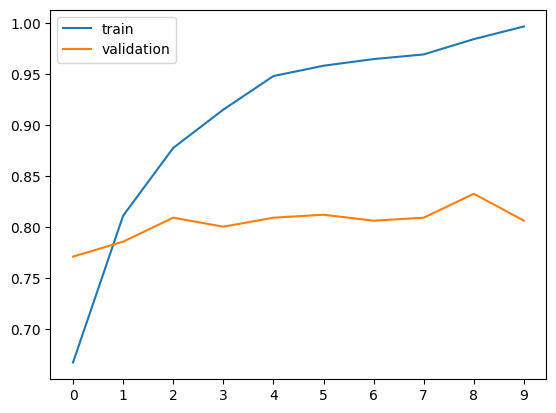

In [52]:
plt.plot(history.history['accuracy'], label = 'train')
plt.plot(history.history['val_accuracy'], label = 'validation')
plt.xticks(np.arange(10))
plt.legend()

## 8.6 Adjusting the Learning Rate

In [53]:
# probably overfitting - so model should be tuned.  One prime target, similar to XGBoost, is the learning rate
# rule of thumb:
#       Low learning rate = highly detailed...but SLOW           validation = could be poor...underfit
#       Med learning rate = OK                                   validation = Good
#       High learning rate = fast                                validation = poor...likely overfit

In [54]:
# let's make a function to evalute different learning rates

def make_model(learning_rate = 0.01):
    base_model = Xception(weights='imagenet', include_top=False, input_shape = (150,150,3))

    base_model.trainable = False

    inputs = keras.Input(shape = (150,150,3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)  # '10' due to the 10 classes we've got, using 'vectors' as the input to the function
    model = keras.Model(inputs, outputs)

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    loss = keras.losses.CategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
    return model

In [ ]:
### DO NOT RUN THIS HERE...IT WILL TAKE FOREVER TO COMPLETE!  See Kaggle notebook
scores = {}

for lr in [0.0001, 0.001, 0.01, 0.1]:
    print (lr)
    model = make_model(learning_rate = lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history
    print()
    print()


In [55]:
# based on examination (see Kaggle), best learning rate is 0.001
learning_rate = 0.001

## 8.7 Checkpointing

In [56]:
# essentially snapshotting model training settings across multiple epochs of training, and holding on to best in class vs. just taking whatever it ends with

## DO NOT RUN - will take FOREVER without GPU assist
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only = True,
    monitor = 'val_accuracy',
    mode = 'max'
)

learning_rate = 0.001

model = make_model(learning_rate = learning_rate)

history = model.fit(
    train_ds,
    epochs = 10,
    validation_data = val_ds,
    callbacks = [checkpoint]
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4753 - loss: 1.5101

96/96 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.6141 - loss: 1.1353 - val_accuracy: 0.7742 - val_loss: 0.7335
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7866 - loss: 0.6363

96/96 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.7816 - loss: 0.6319 - val_accuracy: 0.7889 - val_loss: 0.6171
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8373 - loss: 0.5080

96/96 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.8318 - loss: 0.5080 - val_accuracy: 0.8094 - val_loss: 0.5822
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8545 - loss: 0.4479

96/96 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.8654 - loss: 0.4279 - val_accuracy: 0.8182 - val_loss: 0.5617
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8734 - loss: 0.3971

96/96 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.8810 - loss: 0.3753 - val_accuracy: 0.8299 - val_loss: 0.5448
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9035 - loss: 0.3322 - val_accuracy: 0.8123 - val_loss: 0.5311
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9271 - loss: 0.2708

96/96 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.9179 - loss: 0.2894 - val_accuracy: 0.8387 - val_loss: 0.5218
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9312 - loss: 0.2630 - val_accuracy: 0.8358 - val_loss: 0.5241
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9469 - loss: 0.2318 - val_accuracy: 0.8211 - val_loss: 0.5265
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9524 - loss: 0.2153 - val_accuracy: 0.8211 - val_loss: 0.5252


## 8.8 Adding More layers - 8.9 Regularization and Dropout

In [58]:
#going to add another dense layer
# See Kaggle notebook

## 8.10 Data Augmentation
* Fascinating but totally makes sense.  For image data, consider various transforms (flipping, rotation, etc.) to create "new" data to enhance training